In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

df = pd.read_csv("../data/processed/data_analytics_jobs.csv")

df.head()

,title,jobId,currency,jobUploaded,companyName,tagsAndSkills,experience,salary,location,companyId,ReviewsCount,AggregateRating,jobDescription,minimumSalary,maximumSalary,minimumExperience,maximumExperience
0,Business Analyst,80925008635,INR,9 Days Ago,Acorn Universal Consultancy,"Analytical,PowerBi,Tableau,Power Bi,Analytics,...",4-9 Yrs,Not disclosed,Anand,6749829,23.0,2.4,Analyze business data from multiple sources\nI...,0.0,0.0,4.0,9.0
1,Medical Data Analyst,31025011478,INR,Few Hours Ago,Orcapod Consulting Services,"Medical Data Analyst,Clinical Data Management,...",0-1 Yrs,2.25-3.75 Lacs PA,Chennai,602389,NaN,NaN,Required Skills & Competencies <br><br>Preferr...,225000.0,375000.0,0.0,1.0
2,Capital Market Operations analyst,31025007528,INR,Today,Kashcloud Kpo Services,"Data Analysis,Excel,Trade Reconciliation,Opera...",0-4 Yrs,7-9 Lacs PA,Mathura,123950837,16.0,3.8,"Note: Candidates from Mathura,Agra,Bharatpur,A...",700000.0,900000.0,0.0,4.0
3,"Data Analyst -Excel,Power Query,VBA,Macros and...",260925025850,INR,7 Days Ago,Ifinsol Global,"Excel,VBA,Tableau,Macros,Power Query,Data,Data...",3-8 Yrs,Not disclosed,"Hybrid - Hyderabad, Pune, Bengaluru",842181,NaN,NaN,Qualifications and credentials: . Bachelors de...,0.0,0.0,3.0,8.0
4,Data Analyst (Location - All Over India),260925023413,INR,7 Days Ago,SRS Infoway,"Python,Bigquery,Snowflake,SCALA,Tableau,Domo,S...",6-10 Yrs,Not disclosed,"Hybrid - Pune, Chennai, Bengaluru",1610158,NaN,NaN,Data Modeling experience in Data Warehouse (Sn...,0.0,0.0,6.0,10.0


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (480, 17)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              480 non-null    object 
 1   jobId              480 non-null    int64  
 2   currency           480 non-null    object 
 3   jobUploaded        480 non-null    object 
 4   companyName        480 non-null    object 
 5   tagsAndSkills      476 non-null    object 
 6   experience         476 non-null    object 
 7   salary             480 non-null    object 
 8   location           480 non-null    object 
 9   companyId          480 non-null    int64  
 10  ReviewsCount       338 non-null    float64
 11  AggregateRating    338 non-null    float64
 12  jobDescription     480 non-null    object 
 13  minimumSalary      476 non-null    float64
 14  maximumSalary      476 non-null    float64
 15  minimumExperience  476 non-null    float64
 16  maximumExperience  476 non

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,480,275,Data Analyst,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
jobId,480.0,NaN,NaN,NaN,195451018629.297913,107181708403.905884,11025000296.0,68250015062.25,240925927919.5,270925005428.0,300925922240.0
currency,480,2,INR,479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
jobUploaded,480,14,8 Days Ago,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
companyName,480,308,Gratitude India Manpower Consultants Pvt. Ltd.,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tagsAndSkills,476,456,"business intelligence,qlikview,tableau,waterfa...",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience,476,62,5-10 Yrs,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,480,83,Not disclosed,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,480,122,Bengaluru,93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
companyId,480.0,NaN,NaN,NaN,23449731.870833,46238776.786946,416.0,459817.0,2863780.0,5649745.5,125135297.0


In [6]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values("Missing %", ascending=False)

missing

,Missing Values,Missing %
ReviewsCount,142,29.58
AggregateRating,142,29.58
maximumExperience,4,0.83
minimumExperience,4,0.83
maximumSalary,4,0.83
minimumSalary,4,0.83
tagsAndSkills,4,0.83
experience,4,0.83
jobDescription,0,0.00
title,0,0.00


In [7]:
df.isnull().sum()

title                  0
jobId                  0
currency               0
jobUploaded            0
companyName            0
tagsAndSkills          4
experience             4
salary                 0
location               0
companyId              0
ReviewsCount         142
AggregateRating      142
jobDescription         0
minimumSalary          4
maximumSalary          4
minimumExperience      4
maximumExperience      4
dtype: int64

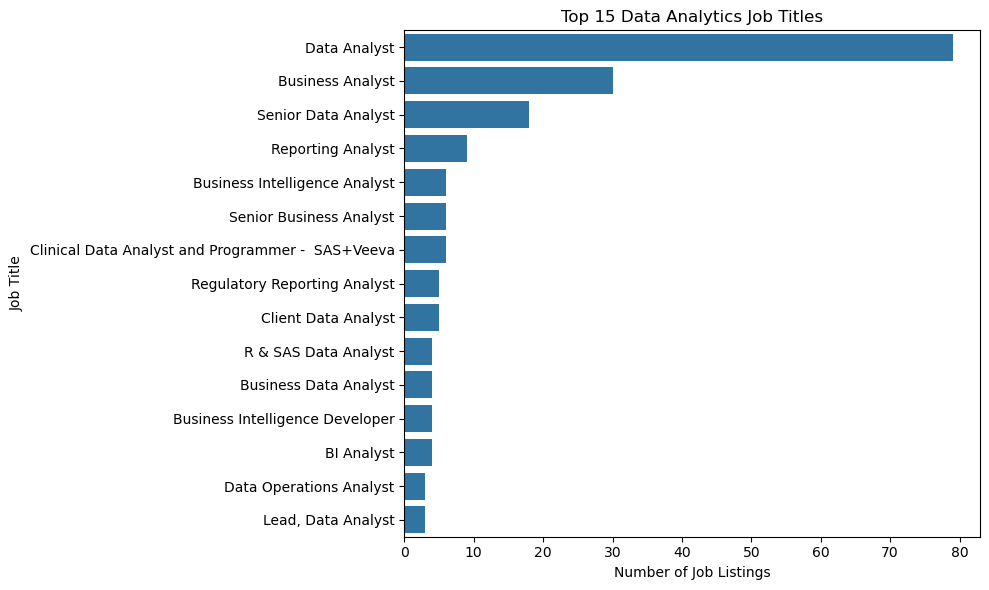

In [8]:
title_counts = df['title'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=title_counts.values, y=title_counts.index)

plt.title('Top 15 Data Analytics Job Titles')
plt.xlabel('Number of Job Listings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

### Job Title Distribution

The job title distribution shows that **Data Analyst** is by far the most frequently advertised role, with nearly 80 listings. **Business Analyst** follows with around 30 listings, while **Senior Data Analyst** accounts for approximately 18 listings. Other roles such as Reporting Analyst, Business Intelligence Analyst, Senior Business Analyst, and Client Data Analyst occur less frequently.

Overall, the distribution indicates that the job market in this dataset is strongly concentrated around **core Data Analyst roles**, while specialized and senior positions have comparatively fewer openings.

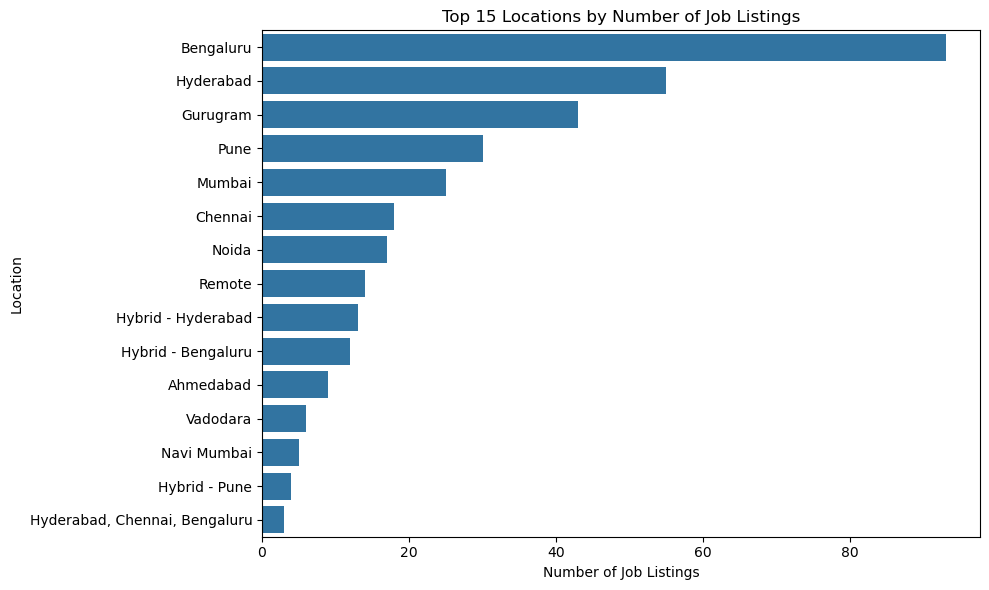

In [22]:
location_counts = df['location'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=location_counts.values, y=location_counts.index)

plt.title('Top 15 Locations by Number of Job Listings')
plt.xlabel('Number of Job Listings')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

### Job Distribution by Location

The location-wise distribution shows that **Bengaluru** has the highest number of Data Analytics job listings, followed by **Hyderabad** and **Gurugram**. **Pune, Mumbai, Chennai, and Noida** also emerge as important hiring locations.

The presence of **Remote** and **Hybrid** listings indicates that Data Analytics opportunities are not limited to traditional office-based roles. Overall, the distribution highlights **Bengaluru, Hyderabad, and Gurugram as the major hiring hubs** in the dataset.

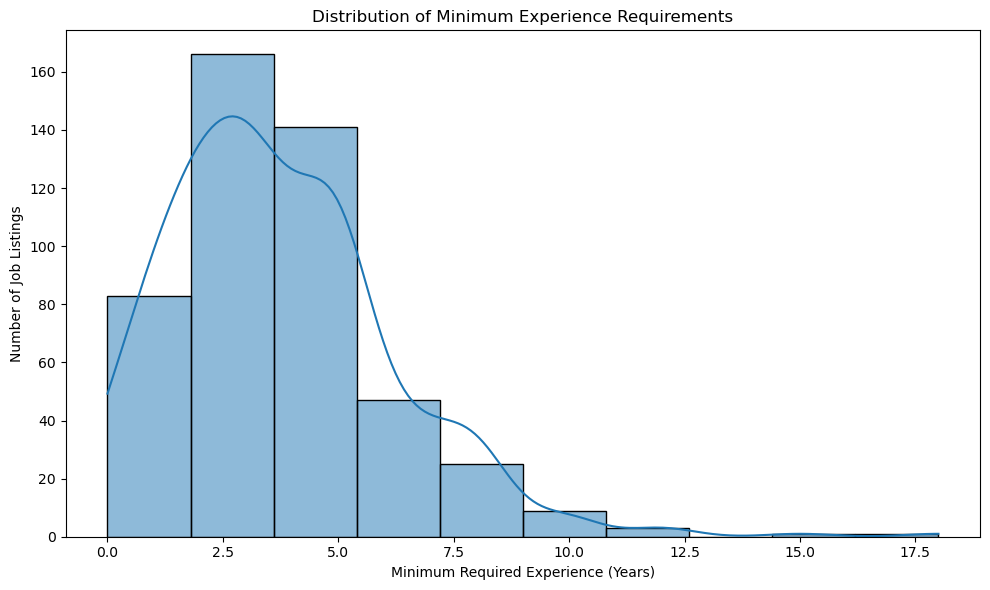

In [10]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['minimumExperience'].dropna(),
    bins=10,
    kde=True
)

plt.title('Distribution of Minimum Experience Requirements')
plt.xlabel('Minimum Required Experience (Years)')
plt.ylabel('Number of Job Listings')
plt.tight_layout()
plt.show()

### Minimum Experience Requirements

The distribution shows that most Data Analytics job listings require a minimum of approximately **2–5 years of experience**. The highest concentration is around **2–3 years**, followed by listings requiring around **4–5 years** of experience.

The number of listings decreases substantially as the minimum experience requirement increases. A small number of positions require more than 8 years of experience, creating a **right-skewed distribution**.

Overall, the dataset indicates that **early-to-mid career professionals with around 2–5 years of experience represent the largest target segment** of the Data Analytics job market.

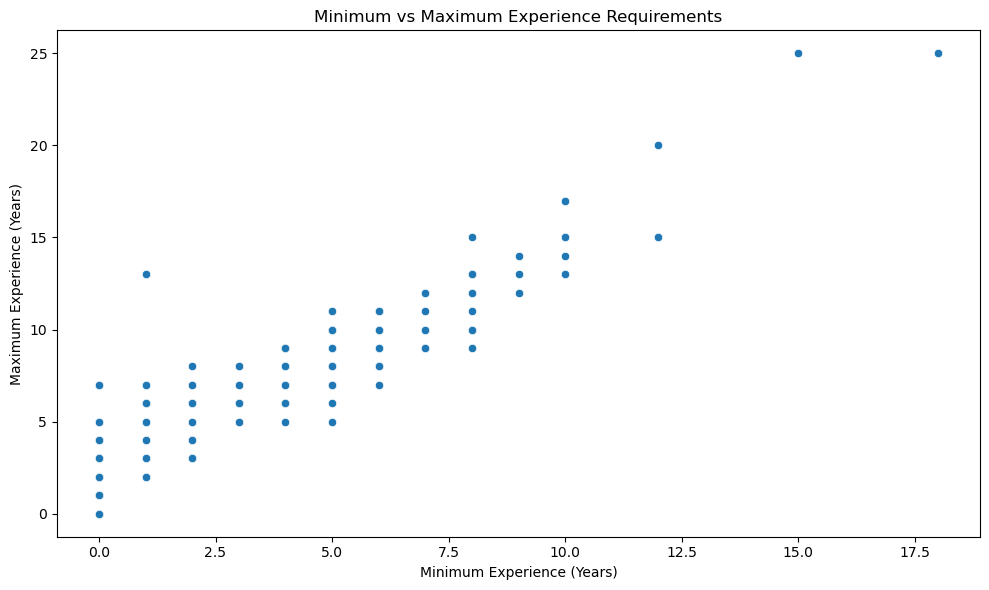

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='minimumExperience',
    y='maximumExperience'
)

plt.title('Minimum vs Maximum Experience Requirements')
plt.xlabel('Minimum Experience (Years)')
plt.ylabel('Maximum Experience (Years)')
plt.tight_layout()
plt.show()

### Minimum vs Maximum Experience Requirements

The scatter plot shows a clear positive relationship between the minimum and maximum experience requirements specified in job listings. Positions with lower minimum requirements generally have narrower and lower experience ranges, while roles requiring higher minimum experience tend to accept candidates with substantially higher levels of experience.

Most job listings are concentrated within the **0–10 year minimum experience range**, with corresponding maximum requirements generally below 15 years. A small number of senior-level positions extend to **20–25 years of maximum experience**.

Overall, the plot indicates that employers tend to define experience ranges consistently with the seniority of the role, with higher minimum requirements associated with broader and more senior experience ranges.

In [14]:
df['tagsAndSkills'].dropna().head(10)

0    Analytical,PowerBi,Tableau,Power Bi,Analytics,...
1    Medical Data Analyst,Clinical Data Management,...
2    Data Analysis,Excel,Trade Reconciliation,Opera...
3    Excel,VBA,Tableau,Macros,Power Query,Data,Data...
4    Python,Bigquery,Snowflake,SCALA,Tableau,Domo,S...
5    Business Analytics,Cyber Security,Business Mod...
6    Computer science,Data analysis,PDF,Analytical,...
7    python,data analysis,analytical,business manag...
8    python,development,data analysis,analytical,do...
9    presentation skills,quantum,capital market,tre...
Name: tagsAndSkills, dtype: object

In [15]:
skills = (
    df['tagsAndSkills']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .str.lower()
)

skills = skills[skills != '']

In [16]:
skill_mapping = {
    'powerbi': 'power bi',
    'power bi': 'power bi',
    'python': 'python',
    'data analysis': 'data analysis',
    'data analytics': 'data analytics',
    'sql': 'sql',
    'excel': 'excel',
    'tableau': 'tableau'
}

skills = skills.replace(skill_mapping)

In [17]:
skill_counts = skills.value_counts()

skill_counts.head(20)

tagsAndSkills
data analysis            223
sql                      173
power bi                 156
python                   142
tableau                   98
data analytics            90
business intelligence     65
data visualization        58
data                      57
bi                        53
excel                     52
business analysis         52
analytical                46
data management           44
data analyst              36
advanced excel            35
analytics                 35
project management        33
macros                    31
data modeling             26
Name: count, dtype: int64

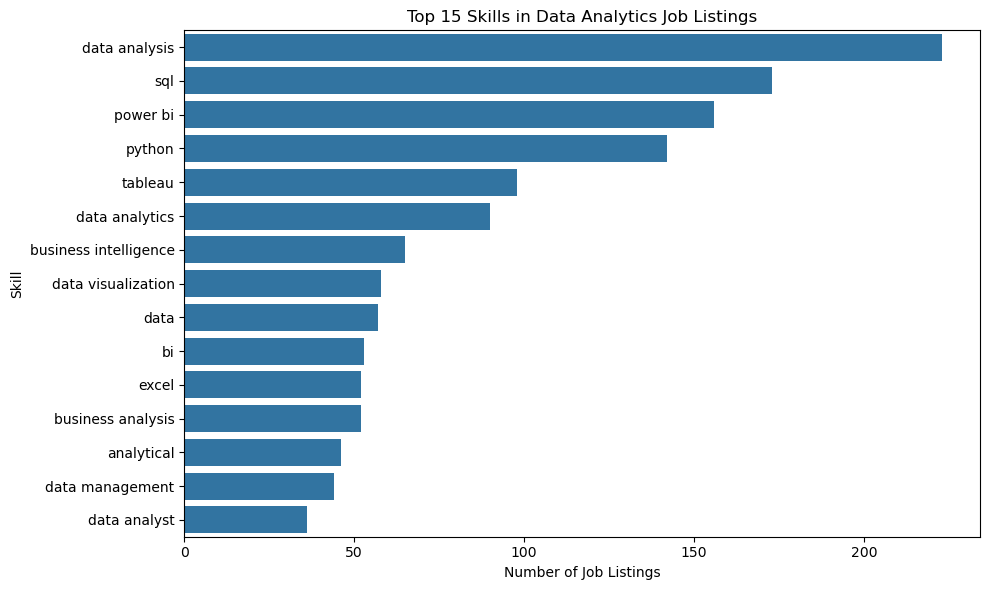

In [18]:
top_skills = skill_counts.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_skills.values,
    y=top_skills.index
)

plt.title('Top 15 Skills in Data Analytics Job Listings')
plt.xlabel('Number of Job Listings')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

In [19]:
technical_skills = [
    'sql',
    'python',
    'power bi',
    'tableau',
    'excel',
    'vba',
    'power query',
    'r',
    'sas',
    'bigquery',
    'snowflake',
    'scala',
    'domo',
    'looker',
    'qlikview',
    'qlik sense',
    'mysql',
    'postgresql',
    'oracle',
    'mongodb',
    'aws',
    'azure',
    'gcp'
]


technical_skill_counts = skills[
    skills.isin(technical_skills)
].value_counts()

technical_skill_counts

tagsAndSkills
sql            173
power bi       156
python         142
tableau         98
excel           52
sas             26
oracle          21
snowflake       18
vba             13
r               12
qlikview         9
power query      9
aws              8
gcp              4
postgresql       3
looker           3
domo             2
bigquery         2
scala            1
mysql            1
qlik sense       1
Name: count, dtype: int64

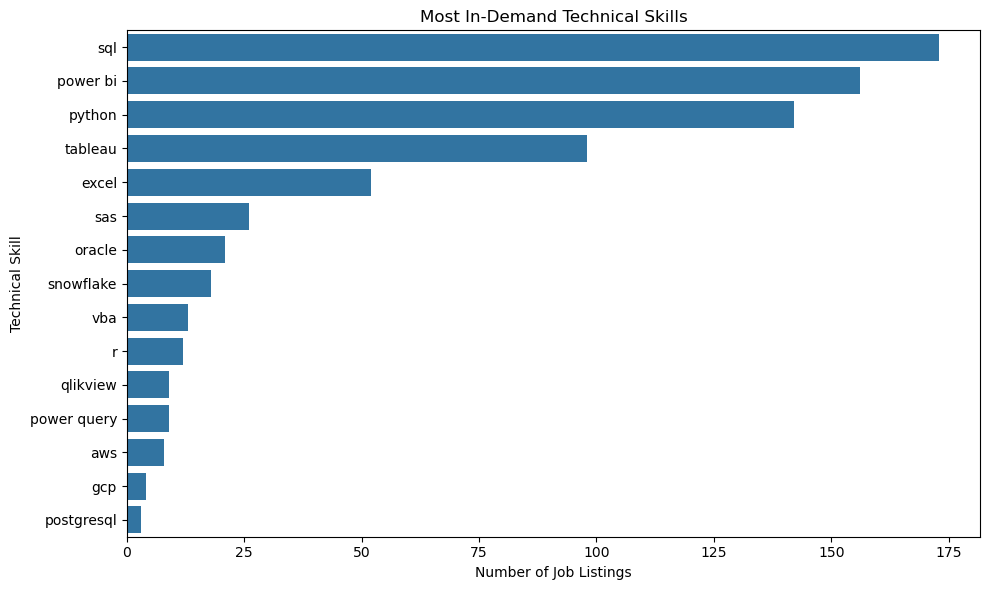

In [20]:
top_technical_skills = technical_skill_counts.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_technical_skills.values,
    y=top_technical_skills.index
)

plt.title('Most In-Demand Technical Skills')
plt.xlabel('Number of Job Listings')
plt.ylabel('Technical Skill')
plt.tight_layout()
plt.show()

### Most In-Demand Technical Skills

The analysis shows that **SQL** is the most frequently demanded technical skill, appearing in the highest number of job listings. **Power BI, Python, and Tableau** are the next most sought-after skills, indicating strong demand for database querying, programming, and data visualization capabilities.

**Excel** also appears prominently, while tools such as **SAS, Oracle, Snowflake, VBA, R, and Power Query** have comparatively lower demand.

Overall, the results suggest that a strong Data Analytics skill set should prioritize **SQL, Power BI, Python, and Tableau**, with Excel providing an additional widely used analytical skill.

Q-3: 

### Industry-wise Hiring

The dataset does not contain an industry or sector field for the job listings. Therefore, industry-wise hiring patterns cannot be reliably determined from the available data without introducing assumptions or external classification methods.

As a result, this business question cannot be directly addressed using the current dataset.

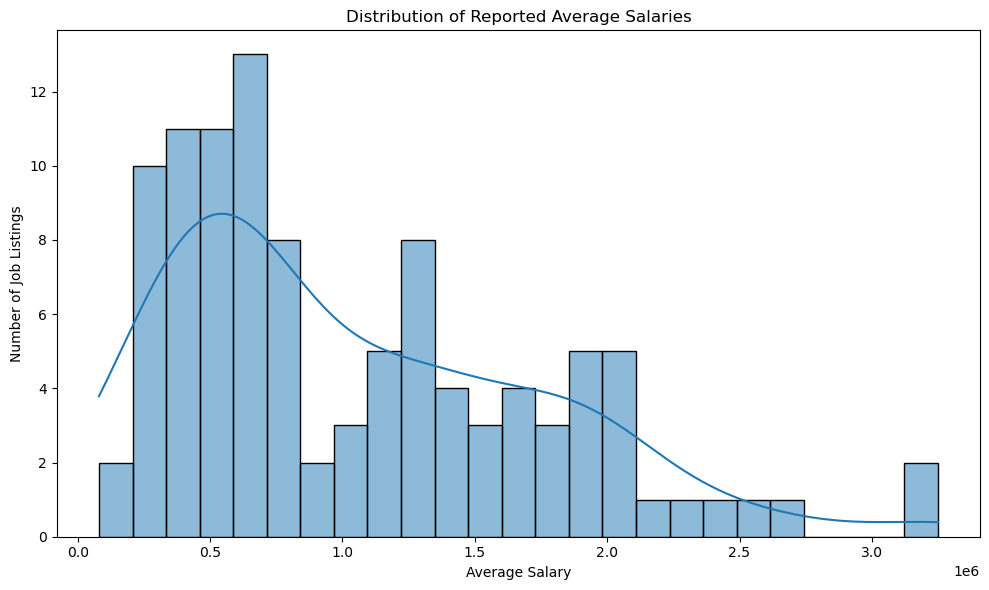

In [23]:
salary_df = df[
    (df['minimumSalary'] > 0) &
    (df['maximumSalary'] > 0)
].copy()

salary_df['averageSalary'] = (
    salary_df['minimumSalary'] + salary_df['maximumSalary']
) / 2


plt.figure(figsize=(10, 6))

sns.histplot(
    salary_df['averageSalary'],
    bins=25,
    kde=True
)

plt.title('Distribution of Reported Average Salaries')
plt.xlabel('Average Salary')
plt.ylabel('Number of Job Listings')
plt.tight_layout()
plt.show()

### Salary Distribution

The distribution of reported average salaries is **right-skewed**, with most reported salaries concentrated in the lower-to-middle range and fewer listings offering substantially higher compensation.

A considerable spread in reported salaries is visible, indicating that compensation varies considerably across Data Analytics roles. The higher salary observations represent a smaller portion of the job market compared with the more concentrated lower salary range.

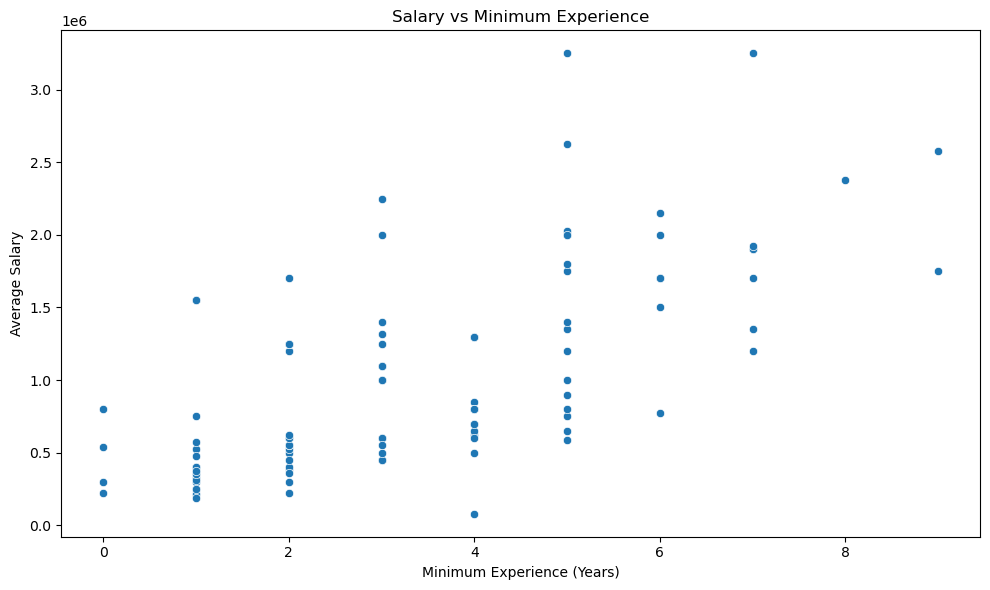

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=salary_df,
    x='minimumExperience',
    y='averageSalary'
)

plt.title('Salary vs Minimum Experience')
plt.xlabel('Minimum Experience (Years)')
plt.ylabel('Average Salary')
plt.tight_layout()
plt.show()

### Salary vs Minimum Experience

The relationship between salary and minimum experience shows a **general upward trend**, with higher experience requirements tending to be associated with higher reported salaries. However, the considerable spread at several experience levels indicates that experience alone does not determine compensation.

Overall, the results suggest that **more experienced Data Analytics roles generally offer higher salaries**, while other factors such as role, location, and job requirements may also contribute to the variation in compensation.

# Business Questions — Summary

### 1. Most In-Demand Technical Skills
SQL emerged as the most frequently demanded technical skill, followed by Power BI, Python, Tableau, and Excel. This indicates that employers primarily seek candidates with strong capabilities in data querying, visualization, programming, and spreadsheet-based analysis.

### 2. Cities with the Highest Job Openings
Bengaluru has the highest number of Data Analytics job listings, followed by Hyderabad and Gurugram. Pune, Mumbai, Chennai, and Noida are also significant hiring hubs.

### 3. Industries Hiring Data Analysts
Industry-wise hiring could not be determined because the dataset does not contain an industry or sector field. Therefore, no assumptions were made to classify companies into industries.

### 4. Salary and Experience Trends
Most positions require approximately 2–5 years of experience, with fewer openings at higher experience levels. Reported salaries are right-skewed, and higher experience requirements generally correspond to higher salaries, although considerable variation exists.